# Chapter 6 — LLMs and RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §6

RLHF · Reward model training · PPO for LLMs · DPO · GRPO · LLMs as RL planners

In [1]:
%pip install -q numpy matplotlib torch
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn, torch.optim as optim

## 6.1 Why RL for LLMs?

Pre-training objective: $\max_\theta\sum_t\log p_\theta(x_t\mid x_{<t})$

This does **not** align with human preference.

**RLHF pipeline:**
1. Supervised Fine-Tuning (SFT) on demonstrations
2. Train Reward Model from pairwise human comparisons
3. Optimise LLM via PPO with KL penalty vs SFT

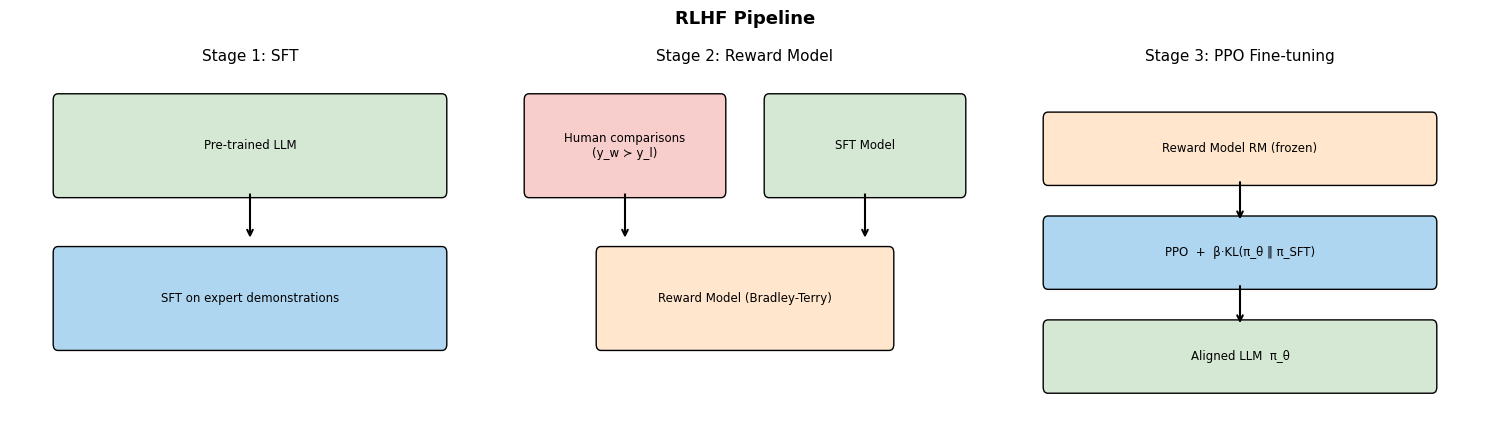

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def box(ax, x, y, w, h, txt, color="#AED6F1"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x,y), w, h, boxstyle="round,pad=0.1", fc=color, ec="black"))
    ax.text(x+w/2, y+h/2, txt, ha="center", va="center", fontsize=8.5)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

for ax in axes:
    ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")

# Stage 1
box(axes[0], 1,4, 8,1.5, "Pre-trained LLM", "#D5E8D4")
arrow(axes[0], 5,4, 5,3.2)
box(axes[0], 1,1.5, 8,1.5, "SFT on expert demonstrations", "#AED6F1")
axes[0].set_title("Stage 1: SFT", fontsize=11)

# Stage 2
box(axes[1], 0.5,4, 4,1.5, "Human comparisons\n(y_w ≻ y_l)", "#F8CECC")
box(axes[1], 5.5,4, 4,1.5, "SFT Model", "#D5E8D4")
arrow(axes[1], 2.5,4, 2.5,3.2); arrow(axes[1], 7.5,4, 7.5,3.2)
box(axes[1], 2,1.5, 6,1.5, "Reward Model (Bradley-Terry)", "#FFE6CC")
axes[1].set_title("Stage 2: Reward Model", fontsize=11)

# Stage 3
box(axes[2], 1,4.2, 8,1, "Reward Model RM (frozen)", "#FFE6CC")
arrow(axes[2], 5,4.2, 5,3.5)
box(axes[2], 1,2.5, 8,1, "PPO  +  β·KL(π_θ ‖ π_SFT)", "#AED6F1")
arrow(axes[2], 5,2.5, 5,1.8)
box(axes[2], 1,0.8, 8,1, "Aligned LLM  π_θ", "#D5E8D4")
axes[2].set_title("Stage 3: PPO Fine-tuning", fontsize=11)

plt.suptitle("RLHF Pipeline", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 6.2 Reward Model — Bradley-Terry Loss

Given pairwise preference $y_w\succ y_l$ for prompt $x$:
$$\mathcal{L}_{\text{RM}}=-\mathbb{E}_{(x,y_w,y_l)}\bigl[\log\sigma(r_\phi(x,y_w)-r_\phi(x,y_l))\bigr]$$

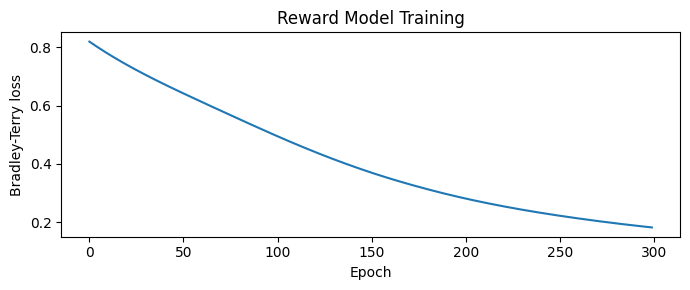

Loss: 0.819 → 0.1818


In [4]:
class RewardModel(nn.Module):
    def __init__(self, d=8, h=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,h), nn.ReLU(), nn.Linear(h,1))
    def forward(self, x): return self.net(x).squeeze(-1)

rng = np.random.default_rng(0)
D, N = 8, 600
w_true = np.array([1.0,0.5,-0.5,0,0,0,0,0])
Xw = rng.standard_normal((N,D)); Xl = rng.standard_normal((N,D))
rw = Xw@w_true; rl = Xl@w_true
flip = rl>rw; Xw[flip],Xl[flip] = Xl[flip].copy(),Xw[flip].copy()
Xw_t = torch.tensor(Xw, dtype=torch.float32)
Xl_t = torch.tensor(Xl, dtype=torch.float32)

rm = RewardModel(); opt = optim.Adam(rm.parameters(), lr=1e-3)
losses = []
for _ in range(300):
    loss = -torch.log(torch.sigmoid(rm(Xw_t)-rm(Xl_t))).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

plt.figure(figsize=(7,3))
plt.plot(losses); plt.xlabel("Epoch"); plt.ylabel("Bradley-Terry loss")
plt.title("Reward Model Training"); plt.tight_layout(); plt.show()
print(f"Loss: {losses[0]:.3f} → {losses[-1]:.4f}")


## 6.3 KL Penalty & DPO

PPO objective with KL regularisation:
$$J(\theta)=\mathbb{E}[r_\phi(x,y)]-\beta\cdot\mathbb{KL}[\pi_\theta\|\pi_{\text{ref}}]$$

**DPO** — no explicit reward model needed:
$$\mathcal{L}_{\text{DPO}}=-\mathbb{E}\Bigl[\log\sigma\Bigl(\beta\log\tfrac{\pi_\theta(y_w\mid x)}{\pi_{\text{ref}}(y_w\mid x)}-\beta\log\tfrac{\pi_\theta(y_l\mid x)}{\pi_{\text{ref}}(y_l\mid x)}\Bigr)\Bigr]$$

Large $\beta$ → conservative (near SFT). Small $\beta$ → reward maximisation (risk of hacking).

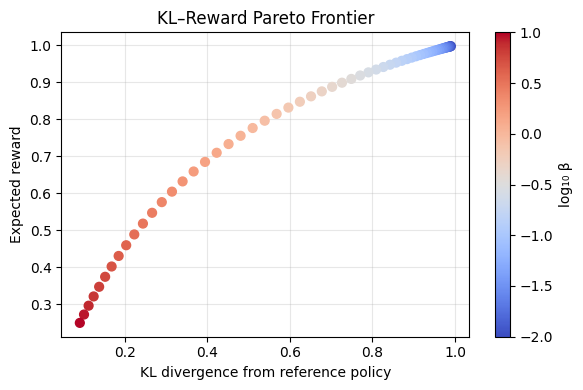

In [5]:
beta_vals = np.logspace(-2, 1, 60)
rewards  = 1.0 / (1 + 0.3*beta_vals)
kl_vals  = 1.0 / (1 + beta_vals)

plt.figure(figsize=(6,4))
sc = plt.scatter(kl_vals, rewards, c=np.log10(beta_vals), cmap="coolwarm", s=40, zorder=5)
plt.colorbar(sc, label="log₁₀ β")
plt.xlabel("KL divergence from reference policy")
plt.ylabel("Expected reward")
plt.title("KL–Reward Pareto Frontier")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 6.4 GRPO (Group Relative Policy Optimization)

Used in DeepSeek-R1. Estimates baseline from **group of samples** rather than a critic:
$$\hat{A}_i = \frac{r_i - \text{mean}(r_{1:G})}{\text{std}(r_{1:G})}$$

Eliminates critic network → simpler, effective for reasoning tasks with verifiable rewards.

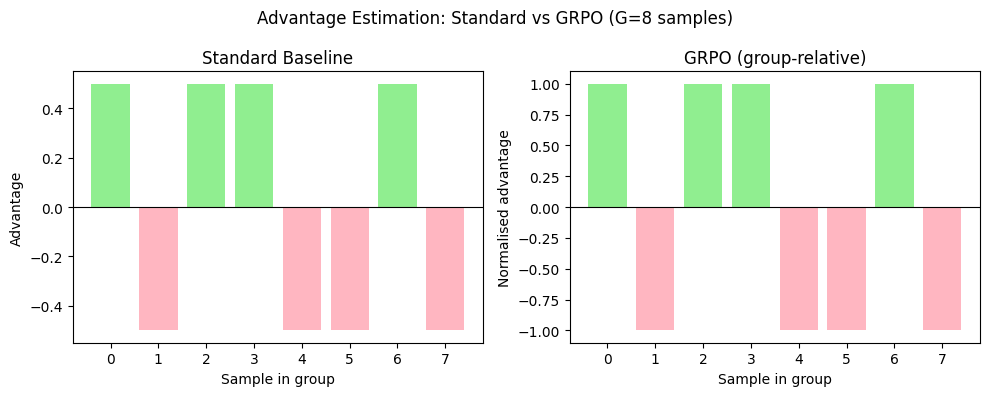

Rewards:          [1, 0, 1, 1, 0, 0, 1, 0]
Standard A:       [0.5, -0.5, 0.5, 0.5, -0.5, -0.5, 0.5, -0.5]
GRPO A (normed):  [1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0]


In [6]:
# Illustrate GRPO advantage estimation vs standard baseline
np.random.seed(42)
G = 8  # group size
true_rewards = np.array([1,0,1,1,0,0,1,0], dtype=float)  # binary (correct/wrong)

# Standard: subtract running mean baseline
baseline_running = 0.5  # suppose running average
A_standard = true_rewards - baseline_running

# GRPO: subtract group mean
A_grpo = (true_rewards - true_rewards.mean()) / (true_rewards.std() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
x = np.arange(G)
axes[0].bar(x, A_standard, color=["#90EE90" if v>0 else "#FFB6C1" for v in A_standard])
axes[0].axhline(0, color="black", lw=0.8); axes[0].set_title("Standard Baseline")
axes[0].set_xlabel("Sample in group"); axes[0].set_ylabel("Advantage")

axes[1].bar(x, A_grpo, color=["#90EE90" if v>0 else "#FFB6C1" for v in A_grpo])
axes[1].axhline(0, color="black", lw=0.8); axes[1].set_title("GRPO (group-relative)")
axes[1].set_xlabel("Sample in group"); axes[1].set_ylabel("Normalised advantage")

plt.suptitle("Advantage Estimation: Standard vs GRPO (G=8 samples)")
plt.tight_layout(); plt.show()
print(f"Rewards:          {true_rewards.astype(int).tolist()}")
print(f"Standard A:       {A_standard.tolist()}")
print(f"GRPO A (normed):  {A_grpo.round(2).tolist()}")
